In [1]:
import torch
import clip
import numpy as np
import pandas as pd
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [70]:
# Load the 1854 labels from the things dataset.
things = np.loadtxt("data/words.csv", dtype=str, delimiter=",")
labels = clip.tokenize(things).to(device)

In [15]:
# Process single image
image = preprocess(Image.open("data/input/window.jpg")).unsqueeze(0).to(device)

In [ ]:
li, lt = model(image, labels)
x = li.softmax(dim=-1).detach().numpy()

In [57]:
window = pd.DataFrame({
    "uniqueID":    np.array(["window"]).repeat(x.shape[1]),
    "label":            things[(-x).argsort()].squeeze(),
    "prob":             -np.sort(-x).squeeze()
})

window

,uniqueID,label,prob
0,window,window,6.812845e-01
1,window,windowsill,7.327873e-02
2,window,wall,1.640949e-02
3,window,door,1.127781e-02
4,window,curtain,1.049265e-02
...,...,...,...
1849,window,headband,5.940163e-08
1850,window,ferris wheel,5.360373e-08
1851,window,seaplane,4.499411e-08
1852,window,manatee,9.782262e-09


In [58]:
window.to_csv("data/clip_scores_window.csv")

Directory of Images

In [4]:
# Process directory of images

import os
import glob
from scipy import stats

files = sorted(glob.glob(os.path.join("data/input", '*.*')))

In [5]:
entropy = np.zeros(len(files))
data = []

for i, file in enumerate(files):
    print("({}/{})  {}".format(i+1, len(files), file))
    image = preprocess(Image.open(file)).unsqueeze(0).to(device)
    
    with torch.no_grad():
        li, _ = model(image, labels)
        pr = li.softmax(dim=-1).cpu().numpy()
    
    data.append(
        pd.DataFrame({
        "file":    np.array([file]).repeat(pr.shape[1]),
        "label":            things[(-pr).argsort()].squeeze(),
        "prob":             -np.sort(-pr).squeeze()
         })
    )

    entropy[i] = stats.entropy(pr.squeeze())

pd.concat(data)

(1/45)  data/input/window.jpg
(2/45)  data/input/window_1.jpg
(3/45)  data/input/window_2.jpg
(4/45)  data/input/window_3.jpg
(5/45)  data/input/window_4.jpg
(6/45)  data/input/window_5.jpg
(7/45)  data/input/window_6.jpg
(8/45)  data/input/window_7.jpg
(9/45)  data/input/window_8.jpg
(10/45)  data/input/wire.jpg
(11/45)  data/input/wire_1.jpg
(12/45)  data/input/wire_2.jpg
(13/45)  data/input/wire_3.jpg
(14/45)  data/input/wire_4.jpg
(15/45)  data/input/wire_5.jpg
(16/45)  data/input/wire_6.jpg
(17/45)  data/input/wire_7.jpg
(18/45)  data/input/wire_8.jpg
(19/45)  data/input/wrist.jpg
(20/45)  data/input/wrist_1.jpg
(21/45)  data/input/wrist_2.jpg
(22/45)  data/input/wrist_3.jpg
(23/45)  data/input/wrist_4.jpg
(24/45)  data/input/wrist_5.jpg
(25/45)  data/input/wrist_6.jpg
(26/45)  data/input/wrist_7.jpg
(27/45)  data/input/wrist_8.jpg
(28/45)  data/input/yarn.jpg
(29/45)  data/input/yarn_1.jpg
(30/45)  data/input/yarn_2.jpg
(31/45)  data/input/yarn_3.jpg
(32/45)  data/input/yarn_4.jp

,file,label,prob
0,data/input/window.jpg,window,9.355469e-01
1,data/input/window.jpg,dollhouse,4.611969e-03
2,data/input/window.jpg,trapdoor,3.944397e-03
3,data/input/window.jpg,magnifying_glass,3.374100e-03
4,data/input/window.jpg,squeegee,2.754211e-03
...,...,...,...
315,data/input/yolk_8.jpg,turtleneck,1.251698e-06
316,data/input/yolk_8.jpg,submarine,1.192093e-06
317,data/input/yolk_8.jpg,polaroid,9.536743e-07
318,data/input/yolk_8.jpg,sweater,5.364418e-07


In [7]:
pd.DataFrame({"file": files, "entropy": entropy}).to_csv("data/clip_scores320.csv")
pd.concat(data).to_csv("data/clip_full320.csv")

All PCRM Images

In [2]:
# Load the 320 labels selected for the PCRM task.
things = np.loadtxt("data/things320.csv", dtype=str, delimiter=",")
labels = clip.tokenize(things).to(device)

In [55]:
files = np.repeat(["data/input/things/{}.jpg".format(concept) for concept in things], 8)
blurs = np.tile(np.arange(8)+1,320)

array([1, 2, 3, ..., 6, 7, 8])

In [80]:
levels = pd.read_csv("data/blurlevels.csv")
concepts = np.sort(levels.uniqueID.unique())

entropy = []
data = []
for i, concept in enumerate(concepts):
    file = "data/input/things/{}.jpg".format(concept)
    print("({}/{})  {}".format(i+1, len(concepts), file))

    baseimage = Image.open(file)

    # for blur, sigma in levels[levels.uniqueID== concept][["blur", "sigma"]].to_numpy():
    for blur, sigma in [(0,0)]:
        print("   level {} blur {}".format(blur, sigma))
        
        image = baseimage#.filter(ImageFilter.GaussianBlur(radius=sigma))
        image = preprocess(image).unsqueeze(0).to(device)

        with torch.no_grad():
            li, _ = model(image, labels)
            pr = li.softmax(dim=-1).cpu().numpy()
        
        data.append(
            pd.DataFrame({
            "file":    np.array([file]).repeat(pr.shape[1]),
            "uniqueID":  np.array([concept]).repeat(pr.shape[1]),
            "blur": np.array([blur]).repeat(pr.shape[1]),
            "label":            things[(-pr).argsort()].squeeze(),
            "prob":             -np.sort(-pr).squeeze()
             })
        )

        entropy.append(
            pd.DataFrame({
            "file":    np.array([file]),
            "uniqueID":  np.array([concept]),
            "blur": np.array([blur]),
            "entropy":   stats.entropy(pr.squeeze())
             })
        )

pd.concat(data)

(1/320)  data/input/things/airboat.jpg
   level 0 blur 0
(2/320)  data/input/things/apple_tree.jpg
   level 0 blur 0
(3/320)  data/input/things/aquarium.jpg
   level 0 blur 0
(4/320)  data/input/things/artichoke.jpg
   level 0 blur 0
(5/320)  data/input/things/backgammon.jpg
   level 0 blur 0
(6/320)  data/input/things/badge.jpg
   level 0 blur 0
(7/320)  data/input/things/baklava.jpg
   level 0 blur 0
(8/320)  data/input/things/banana_peel.jpg
   level 0 blur 0
(9/320)  data/input/things/bank.jpg
   level 0 blur 0
(10/320)  data/input/things/basil.jpg
   level 0 blur 0
(11/320)  data/input/things/bathrobe.jpg
   level 0 blur 0
(12/320)  data/input/things/baton4.jpg
   level 0 blur 0
(13/320)  data/input/things/battery.jpg
   level 0 blur 0
(14/320)  data/input/things/bedpan.jpg
   level 0 blur 0
(15/320)  data/input/things/belt.jpg
   level 0 blur 0
(16/320)  data/input/things/belt_buckle.jpg
   level 0 blur 0
(17/320)  data/input/things/binoculars.jpg
   level 0 blur 0
(18/320)  data

,file,uniqueID,blur,label,prob
0,data/input/things/airboat.jpg,airboat,0,airboat,0.999023
1,data/input/things/airboat.jpg,airboat,0,hovercraft,0.000179
2,data/input/things/airboat.jpg,airboat,0,boat,0.000112
3,data/input/things/airboat.jpg,airboat,0,metal detector,0.000051
4,data/input/things/airboat.jpg,airboat,0,speedboat,0.000043
...,...,...,...,...,...
1849,data/input/things/yolk.jpg,yolk,0,gargoyle,0.000000
1850,data/input/things/yolk.jpg,yolk,0,walrus,0.000000
1851,data/input/things/yolk.jpg,yolk,0,space shuttle,0.000000
1852,data/input/things/yolk.jpg,yolk,0,poinsettia,0.000000


In [81]:
pd.concat(entropy).to_csv("data/clip_scores1854_all_noblur.csv")
pd.concat(data).to_csv("data/clip_full1854_all_noblur.csv")

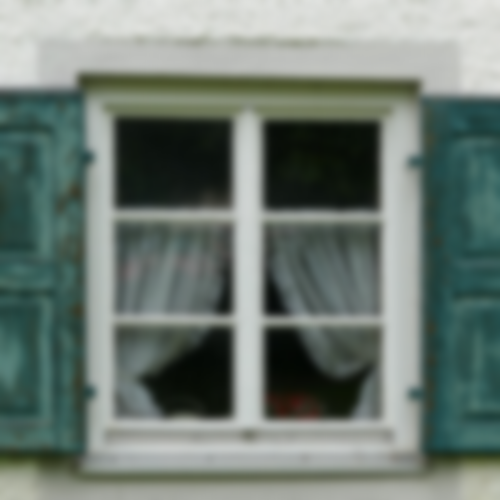

In [69]:
from PIL import ImageFilter


image = Image.open("data/input/window.jpg")
image = image.filter(ImageFilter.GaussianBlur(radius=4))
#preprocess(image).unsqueeze(0).to(device)
image

